In [34]:
import pandas as pd
import os
import sys

import geojson
from shapely import Polygon

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_dir)

from src.io import *
from src.geometry import *
from src.utils import *
from src.viz import *
from src.core import *

In [35]:
region = 'netherlands'
level = 'states'

In [36]:
# polygons, target_areas, target_positions, names, centroid = loader(region, level, year=2020)

In [37]:
# plot_polys(polygons, title="Original Polygons", legend=False)

In [38]:
# horizontal_pairs, vertical_pairs = disjoint_pairs_horizontal_and_vertical_center(polygons)

In [39]:
# new_polys, areas, status, val, leaders, target_areas = \
#     CartogramFramework_global(
#         polygons=polygons,
#         target_areas=target_areas,
#         fixed_points=None,             # → uses polygon centroids as origins
#         shape="square",             # "circle", "square", or "contiguous"
#         target_centers=target_positions,
#         horizontal_pairs=horizontal_pairs,
#         vertical_pairs=vertical_pairs,
#         neighboring_pairs=neighbouring_pairs(polygons),
#         shared_vertices_of_neighbors=shared_vertices_of_neighbors(polygons),

#         lambda_shape=0.1,    # small; E_square ≈ 0 once squares are pre-built # Demers: 0.1
#         lambda_area=1.0,      # Demers 1.0
#         lambda_center=0.0,    # TOP variant (Fig. 1 left) — purely minimise gaps # Demers: 0,0
#         lambda_topology=1.0,  # paper's objective (1): min Σ h_ij + v_ij # Demers: 1.0

#         gamma=0.0,            # pure E_square — REQUIRED for Demers
#         beta=1.0,
#         alpha=1.0,
#         epsilon=1e-2,
#         b=1e-2,
#         t_min=0.01,
#         shape_deformation=0.0,  # triggers make_square() until patch is applied
#     )
# plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

In [40]:
# original_areas = [polygon_areanp(poly) for poly in polygons]

# for area, target_area, original_area in zip(areas, target_areas, original_areas):
#     print(f"Area: {area:.2f}, Target Area: {target_area:.2f}, Difference: {abs(area - target_area):.2f}")
#     print(f"Original Area: {original_area:.2f}, Difference from Original: {abs(area - original_area):.2f}")


prevent_vertex_penetration False Master on/off switch
penetration_pairs None Restrict to specific pairs (all neighbours if None)
penetration_margin 0.0 Extra clearance beyond the border edge
penetration_use_all_edges False False = shared border edges only (recommended); True = all edges of j

In [41]:
# # Force t fixed at 1, no shape deformation, no contiguous pulling
# new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
#     polygons          = polygons,
#     target_areas      = target_areas,   # unchanged
#     fixed_points      = None,
#     shape             = "original",     # no contiguous pulling
#     target_centers    = target_positions,
#     lambda_shape      = 0.0,            # ← disable shape term
#     lambda_area       = 0.0,            # ← disable area term
#     lambda_center     = 0.0,
#     lambda_topology   = 0.0,
#     lambda_contiguous = 0.0,            # ← disable contiguous
#     soft_mean_scale   = False,          # ← disable mean scale
#     t_min             = 1.0,            # ← pin t to exactly 1
#     t_max             = 1.0,            # ← pin t to exactly 1
# )
# plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

Why the Map Changes Despite Identity Targets
1. t_min = 0.01 and t_max = 1.5 clip the homothetic scales
The original polygon has some vertices with scale t_ik = 1.0 (identity). But your bounds force t ∈ [0.01, 1.5]. If any original vertex had an implicit scale outside this range, it gets clipped. More importantly, the optimizer is free to move t anywhere in [0.01, 1.5] — it will, because other objective terms pull it away from 1.0.
2. lambda_shape = 0.5 actively deforms polygons
The shape term minimizes deviation from the target shape (controlled by gamma = 1.0). With gamma = 1.0 the shape term is purely the E_target component — deformation toward a regularized/smoothed version of the polygon, not toward the original vertices. This will move vertices even when areas are unchanged.
3. lambda_contiguous = 80.0 with contiguous2 moves shared vertices
The soft penalty pulls shared border vertices of neighbours toward each other. Even at identity areas, if two polygons' shared vertices don't perfectly coincide in the initial geometry (numerical tolerance), the penalty drags them together — changing both polygons.
4. soft_mean_scale = True with lambda_mean_scale = 1e4 enforces mean scale ≈ target
The mean scale penalty forces mean(t_ik) ≈ s_i where s_i is derived from target_area / original_area. Even at identity, if the polygon vertices don't distribute perfectly around the fixed point, the mean of the t_ik values at the original geometry ≠ 1.0 exactly, so the solver shifts them.
5. fixed_points = None means centroids are recomputed
With fixed_points = None, the framework computes fixed points (likely centroids or weighted centroids) internally. The homothetic transform is v'_ik = m_i + t_ik * d_ik where d_ik = v_ik - fp_i. If fp_i is not exactly the centroid used in the direction computation, the "identity" transform t_ik = 1 doesn't reconstruct the original polygon exactly.


In [42]:
# new_polys, areas, status, val, leaders, target_areas = CartogramFramework_global(
#     polygons        = polygons,
#     target_areas    = target_areas,
#     fixed_points    = None,
#     shape           = "contiguous2",
#     target_centers  = target_positions,
#     horizontal_pairs = horizontal_pairs,
#     vertical_pairs   = vertical_pairs,
#     neighboring_pairs = neighbouring_pairs(polygons),
#     shared_vertices_of_neighbors = shared_vertices_of_neighbors(polygons),

#     lambda_shape      = 0.5,
#     lambda_area       = 1.0,
#     lambda_center     = 0.0,
#     lambda_topology   = 0.0,
#     lambda_contiguous = 80.0,
#     soft_mean_scale   = True,
#     lambda_mean_scale = 1e4,
#     t_min = 0.01,
#     t_max = 1.5,
#     lambda_vertex_distance = 10.0,
#     vertex_distance_margin = 1.5,
#     lambda_repulsion  = 0.0,
#     contiguous_area_ratio_cap = np.inf,
#     contiguous_use_topology   = False,
#     gamma = 1.0,
#     beta  = 1.0,
#     alpha = 1.0,
#     epsilon = 1e-2,
#     b       = 1e-2,

#     # prevent_vertex_penetration = True,
#     postprocess_fill_holes = True,

#     # ── Post-processing ───────────────────────────────────────────
#     postprocess_contiguous  = True,     # flip to False to skip entirely
#     postprocess_snap_method = "mean",   # midpoint snap on shared vertices
# )
# plot_polys(new_polys, title="Optimized Polygons", centroids=False, legend=False, target_centers=None)

In [43]:
# original_areas = [polygon_areanp(poly) for poly in polygons]

# for area, target_area, original_area in zip(areas, target_areas, original_areas):
#     print(f"Area: {area:.2f}, Target Area: {target_area:.2f}, Difference: {abs(area - target_area):.2f}")
#     print(f"Original Area: {original_area:.2f}, Difference from Original: {abs(area - original_area):.2f}")


In [44]:
base_path = "/home/kuenem/Documents/development/lectures/Master Thesis/Cartogram Framework/"
path = os.path.join(base_path, "data/geojson/contiguous/world/world.geojson")

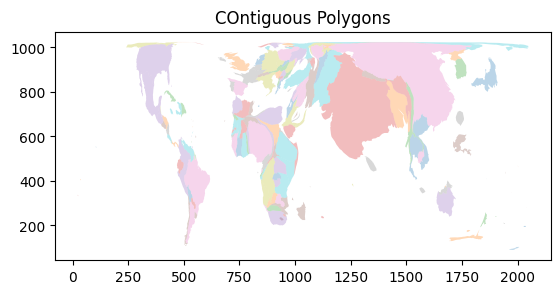

In [45]:
polygons, target_areas, target_positions, names, centroid = get_polygon_data(path, exclude=None)
# print(polygons)
plot_polys(polygons, title="COntiguous Polygons", legend=False)

In [46]:
def true_target_areas(populations: dict, original_areas: dict):
    """Population-proportional target, normalized to the ORIGINAL total area
    — this matches Eq. 3.1 in your thesis and is projection/tool-independent."""
    total_pop = sum(populations.values())
    total_area = sum(original_areas.values())
    return {k: (populations[k] / total_pop) * total_area for k in populations}

def cartographic_error(measured_areas: dict, target_areas: dict):
    errors = {}
    for region_id, target in target_areas.items():
        measured = measured_areas.get(region_id)
        if measured is None:
            continue  # flag missing joins separately, don't silently skip in your real pipeline
        errors[region_id] = abs(measured - target) / max(measured, target)
    e_a = sum(errors.values()) / len(errors)   # average cartographic error
    e_inf = max(errors.values())               # maximum cartographic error
    return e_a, e_inf, errors

In [47]:
df = pd.read_csv(os.path.join(base_path, "data/statistics/contiguous/world/2010.csv"))
df = df.set_index("ISO_CODE")

In [48]:
total_target = 0
total_area = 0
for polygon, name in zip(polygons, names):
    poly = Polygon(polygon)
    target = df.loc[name, "Population (people)"]
    total_target += target
    total_area += poly.area
    print(f"Polygon: {name}, Target: {target}, Area: {polygon_areanp(polygon):.2f}, Shapely Area: {poly.area:.2f}")

Polygon: AFG, Target: 38326027, Area: 2715.34, Shapely Area: 2715.34
Polygon: GBR, Target: 66951174, Area: 4533.13, Shapely Area: 4533.13
Polygon: ALB, Target: 2872130, Area: 203.46, Shapely Area: 203.46
Polygon: DZA, Target: 43090987, Area: 3052.66, Shapely Area: 3052.66
Polygon: USA, Target: 335388238, Area: 19588.28, Shapely Area: 19588.28
Polygon: ATG, Target: 92377, Area: 4.56, Shapely Area: 4.56
Polygon: ARG, Target: 44908441, Area: 3123.10, Shapely Area: 3123.10
Polygon: AND, Target: 77020, Area: 5.45, Shapely Area: 5.45
Polygon: AGO, Target: 32898997, Area: 2317.11, Shapely Area: 2317.11
Polygon: ARM, Target: 2812496, Area: 199.13, Shapely Area: 199.13
Polygon: NLD, Target: 17402277, Area: 1210.99, Shapely Area: 1210.99
Polygon: AUS, Target: 25544179, Area: 1766.77, Shapely Area: 1766.77
Polygon: AUT, Target: 8901106, Area: 630.71, Shapely Area: 630.71
Polygon: AZE, Target: 10273528, Area: 693.58, Shapely Area: 693.58
Polygon: BHS, Target: 405779, Area: 13.55, Shapely Area: 13.

In [49]:
for polygon, name in zip(polygons, names):
    target = df.loc[name, "Population (people)"]
    poly = Polygon(polygon)
    print(f"Error: {target/total_target - poly.area/total_area:.2f}")

Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.01
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.01
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: 0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Error: -0.00
Err